# 030 — Evaluation

Quantitative comparison of UNet, ResUNet, Attention UNet, and EfficientNet UNet on the
held-out test set, followed by qualitative examples (best and worst predictions per architecture).

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import build_dataset, grouped_train_val_test_split, load_image_pairs
from scripts.trainer import load_model
from scripts.visualization import plot_predictions

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Build test dataset

In [3]:
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
_, _, test_pairs = grouped_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    seed=settings.SEED,
)

test_ds = build_dataset(
    test_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)
print(f"Test pairs: {len(test_pairs)} | Test batches: {len(test_ds)}")

Test pairs: 115 | Test batches: 15


2026-06-04 00:54:25.430082: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-06-04 00:54:25.430112: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-04 00:54:25.430121: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-04 00:54:25.430139: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-04 00:54:25.430153: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 2. Evaluate all models

In [4]:
ARCH_CONFIGS = {
    "unet":              {"advanced_loss": False},
    "resunet":           {"advanced_loss": False},
    "attention_unet":    {"advanced_loss": False},
    "efficientnet_unet": {"advanced_loss": True},
}
results: dict = {}

for arch, load_kwargs in ARCH_CONFIGS.items():
    try:
        model = load_model(
            arch,
            model_dir=settings.MODELS_DIR,
            lr=settings.LEARNING_RATE,
            loss_alpha=settings.LOSS_ALPHA,
            **load_kwargs,
        )
    except FileNotFoundError as exc:
        print(f"[skip] {exc}")
        continue

    print(f"Evaluating {arch}...")
    metrics = model.evaluate(test_ds, verbose=0, return_dict=True)
    results[arch] = metrics
    print(f"  {arch}: { {k: f'{v:.4f}' for k, v in metrics.items()} }")

Evaluating unet...


2026-06-04 00:54:29.789947: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  unet: {'loss': '0.2563', 'mae': '0.1877', 'psnr': '14.8271', 'ssim': '0.5835'}
Evaluating resunet...
  resunet: {'loss': '0.2488', 'mae': '0.1784', 'psnr': '15.2724', 'ssim': '0.5868'}
Evaluating attention_unet...
  attention_unet: {'loss': '0.2607', 'mae': '0.1932', 'psnr': '14.5314', 'ssim': '0.5820'}
Evaluating efficientnet_unet...
  efficientnet_unet: {'loss': '0.0726', 'mae': '0.1251', 'psnr': '16.7970', 'ssim': '0.2637'}


## 3. Comparison table

In [5]:
if results:
    col_w = 14
    headers = ["architecture"] + list(next(iter(results.values())).keys())
    print("".join(h.ljust(col_w) for h in headers))
    print("-" * (col_w * len(headers)))
    for arch, metrics in results.items():
        row = [arch] + [f"{v:.4f}" for v in metrics.values()]
        print("".join(c.ljust(col_w) for c in row))

architecture  loss          mae           psnr          ssim          
----------------------------------------------------------------------
unet          0.2563        0.1877        14.8271       0.5835        
resunet       0.2488        0.1784        15.2724       0.5868        
attention_unet0.2607        0.1932        14.5314       0.5820        
efficientnet_unet0.0726        0.1251        16.7970       0.2637        


## 4. Bar chart comparison

/var/folders/zb/s5bg_j794dd0zl1hvkwlj1m80000gn/T/ipykernel_3944/1125568049.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(archs, rotation=20, ha="right")
/var/folders/zb/s5bg_j794dd0zl1hvkwlj1m80000gn/T/ipykernel_3944/1125568049.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(archs, rotation=20, ha="right")
/var/folders/zb/s5bg_j794dd0zl1hvkwlj1m80000gn/T/ipykernel_3944/1125568049.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(archs, rotation=20, ha="right")
/var/folders/zb/s5bg_j794dd0zl1hvkwlj1m80000gn/T/ipykernel_3944/1125568049.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
 

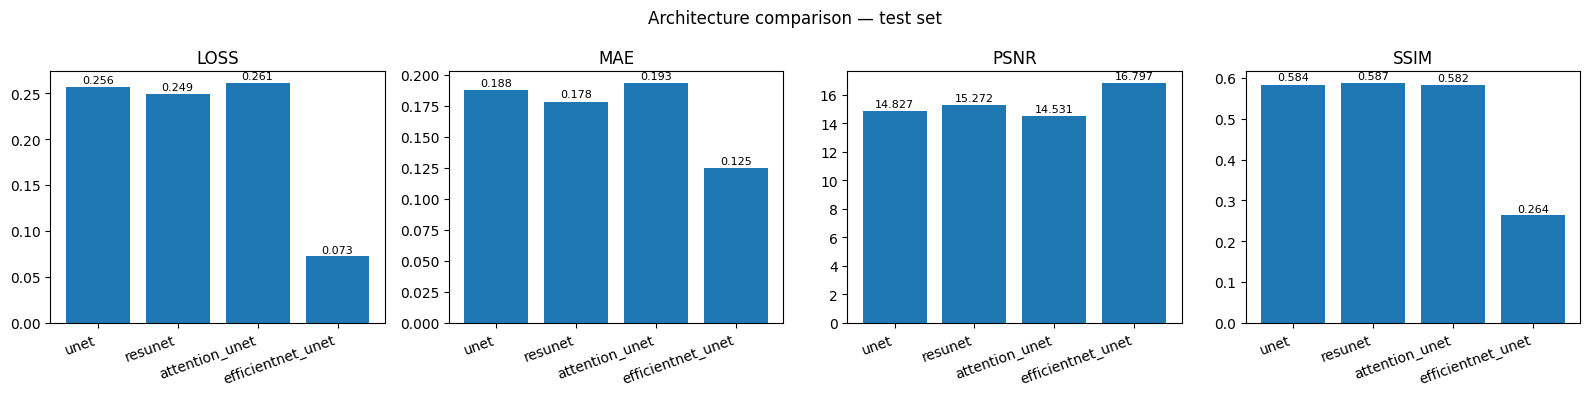

In [6]:
if results:
    metric_keys = list(next(iter(results.values())).keys())
    n = len(metric_keys)
    archs = list(results.keys())
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    fig.suptitle("Architecture comparison — test set")
    for ax, key in zip(axes, metric_keys):
        vals = [results[a][key] for a in archs]
        bars = ax.bar(archs, vals)
        ax.set_title(key.upper())
        ax.set_xticklabels(archs, rotation=20, ha="right")
        for bar, v in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f"{v:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()

## 5. Qualitative gallery — 5 test samples per architecture

In [ ]:
N_DISPLAY = 5

for arch, load_kwargs in ARCH_CONFIGS.items():
    try:
        model = load_model(
            arch,
            model_dir=settings.MODELS_DIR,
            lr=settings.LEARNING_RATE,
            loss_alpha=settings.LOSS_ALPHA,
            **load_kwargs,
        )
    except FileNotFoundError:
        continue

    print(f"\n--- {arch} ---")
    sample_ds = build_dataset(test_pairs[:N_DISPLAY], batch_size=1, augment=False, shuffle=False)

    for (rgb_batch, ir_batch), pair in zip(sample_ds, test_pairs[:N_DISPLAY]):
        ir_pred = model.predict(rgb_batch, verbose=0)
        fig = plot_predictions(
            rgb_batch[0].numpy(),
            ir_batch[0].numpy(),
            ir_pred[0],
            title=f"{arch} — {Path(pair[0]).stem}",
        )
        plt.show()

## 6. Worst predictions (lowest SSIM)

In [ ]:
from scripts.metrics import SSIMMetric

N_WORST = 3

for arch, load_kwargs in ARCH_CONFIGS.items():
    try:
        model = load_model(
            arch,
            model_dir=settings.MODELS_DIR,
            lr=settings.LEARNING_RATE,
            loss_alpha=settings.LOSS_ALPHA,
            **load_kwargs,
        )
    except FileNotFoundError:
        continue

    ssim_scores: list[tuple[float, int]] = []
    single_ds = build_dataset(test_pairs, batch_size=1, augment=False, shuffle=False)

    for idx, (rgb_batch, ir_batch) in enumerate(single_ds):
        ir_pred = model.predict(rgb_batch, verbose=0)
        ssim_val = float(
            tf.reduce_mean(tf.image.ssim(ir_batch, tf.constant(ir_pred), max_val=1.0))
        )
        ssim_scores.append((ssim_val, idx))

    worst = sorted(ssim_scores)[:N_WORST]
    print(f"\n--- {arch}: {N_WORST} worst predictions (SSIM) ---")
    for ssim_val, idx in worst:
        rgb_path, ir_path = test_pairs[idx]
        rgb_batch, ir_batch = next(iter(build_dataset([test_pairs[idx]], batch_size=1)))
        ir_pred = model.predict(rgb_batch, verbose=0)
        fig = plot_predictions(
            rgb_batch[0].numpy(),
            ir_batch[0].numpy(),
            ir_pred[0],
            title=f"{arch} | SSIM={ssim_val:.3f} | {Path(rgb_path).stem}",
        )
        plt.show()